# <span style="color:orange">INARA Model Visualisation </span>

**Models inspected:**
- `models/baseline_rf.joblib` — per-molecule Random Forest (PCA features)
- `models/cnn1d.pt` — 1D CNN (raw spectra)

**Contents:**
1. Load models and pre-computed results
2. Training history (deep model loss curve)
3. Model comparison — R² per molecule
4. Predicted vs Actual scatter plots
5. Residual (error) distributions
6. RF feature importance — top PCA components per molecule
7. 1D CNN architecture — parameter counts per layer

In [28]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import joblib
import torch

ROOT = Path('..').resolve()
sys.path.insert(0, str(ROOT))

from src.data_utils import MOLECULE_NAMES
from src.baseline_model import BaselineModel
from src.deep_model import CNN1D, MOLECULE_HEAD_CONFIGS

plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.size': 11,
})

RESULTS_DIR = ROOT / 'results' / 'processed'
MODELS_DIR  = ROOT / 'models'

print('Paths OK:', RESULTS_DIR.exists(), MODELS_DIR.exists())

Paths OK: True True


## 0. Input Visualisation — CLIMA Profiles as 2D Heatmaps

Each input sample is a `(12, 101)` matrix: **12 CLIMA channels** (rows) × **101 altitude levels** (columns, surface→top).  
Side-by-side samples show how different each planet's atmospheric profile is.

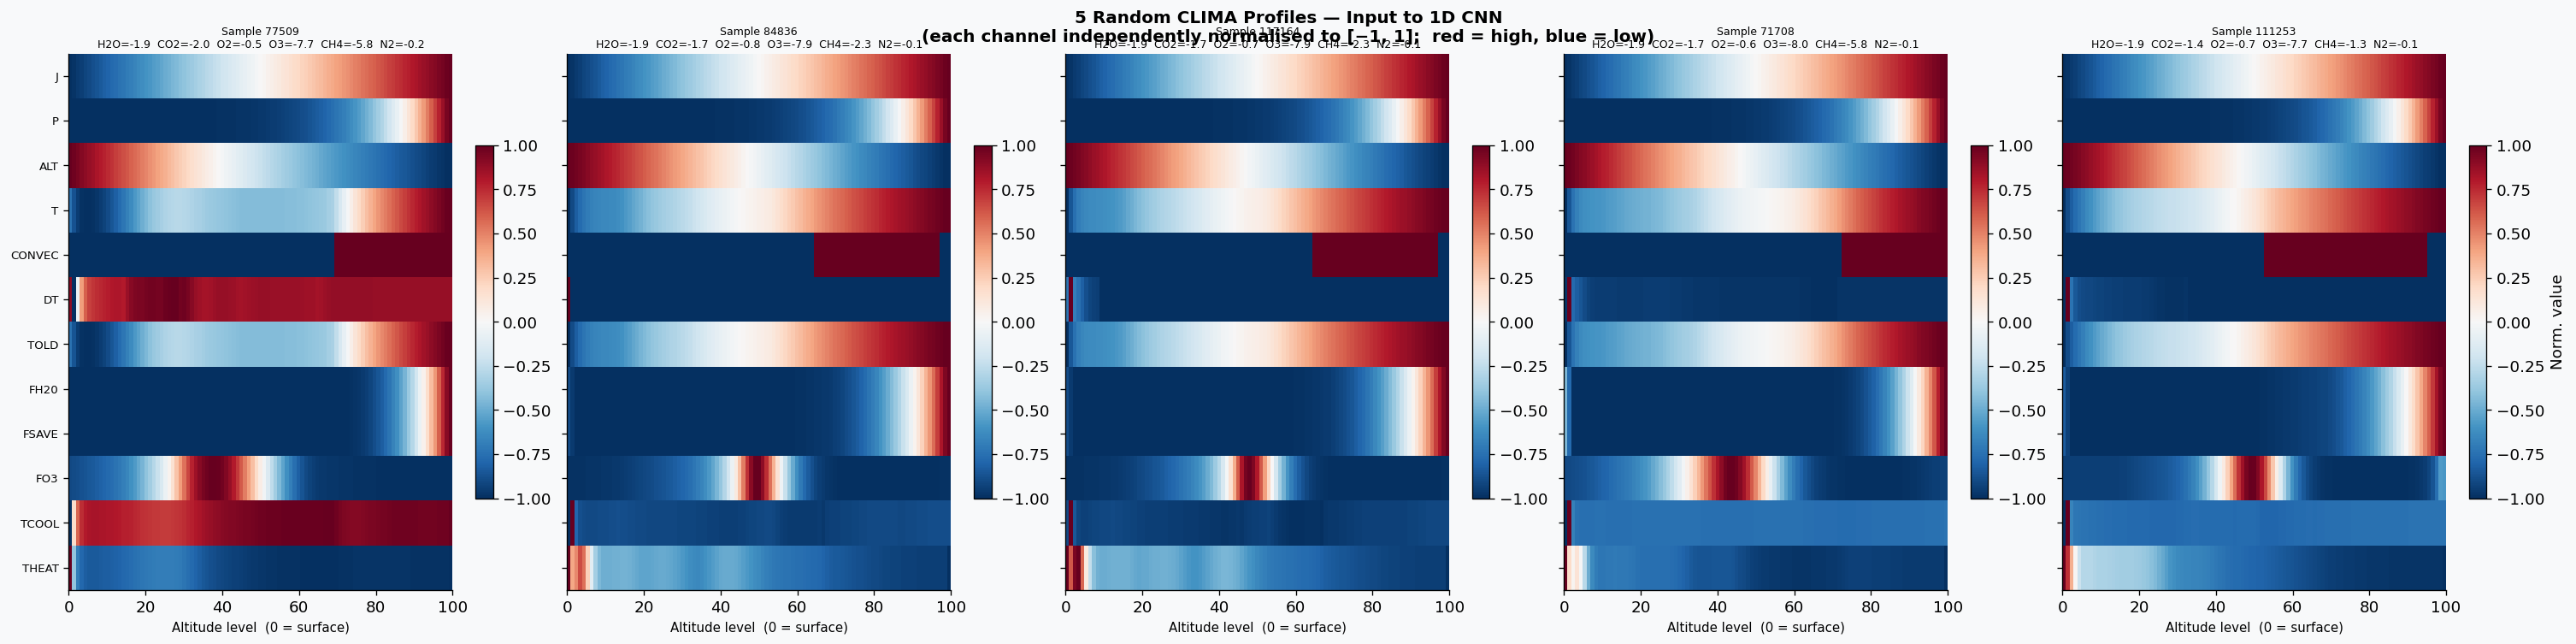

In [29]:
import json
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from matplotlib.colors import TwoSlopeNorm

DATA_DIR = ROOT / 'inara_data' / 'processed'

spectra    = np.load(DATA_DIR / 'spectra.npy')     # (N, 12, 101)
molecules  = np.load(DATA_DIR / 'molecules.npy')   # (N, 12)
altitude   = np.load(DATA_DIR / 'wavelengths.npy') # (101,) km

with open(DATA_DIR / 'dataset_info.json') as f:
    info = json.load(f)
CLIMA_NAMES = info['clima_channels']

# Pick 5 diverse samples — spread across the dataset
rng        = np.random.default_rng(7)
sample_idx = rng.choice(len(spectra), size=5, replace=False)

N_SAMPLES  = len(sample_idx)
fig, axes  = plt.subplots(1, N_SAMPLES, figsize=(N_SAMPLES * 5, 6),
                           constrained_layout=True)
fig.patch.set_facecolor('#F8F9FA')

for col, idx in enumerate(sample_idx):
    ax  = axes[col]
    img = spectra[idx]          # (12, 101)

    # Per-channel normalise to [-1, 1] so all channels are visible on the same scale
    ch_min = img.min(axis=1, keepdims=True)
    ch_max = img.max(axis=1, keepdims=True)
    denom  = np.where((ch_max - ch_min) < 1e-10, 1.0, ch_max - ch_min)
    img_norm = 2 * (img - ch_min) / denom - 1   # → [-1, 1] per channel

    im = ax.imshow(img_norm, aspect='auto', cmap='RdBu_r',
                   vmin=-1, vmax=1,
                   extent=[altitude[0], altitude[-1], 11.5, -0.5])

    ax.set_xlabel('Altitude level  (0 = surface)', fontsize=9)
    ax.set_yticks(range(12))
    ax.set_yticklabels(CLIMA_NAMES, fontsize=8)
    if col > 0:
        ax.set_yticklabels([])

    # Molecule abundances as title annotation
    mol_lines = '  '.join(
        f'{m}={molecules[idx, i]:.1f}' for i, m in enumerate(MOLECULE_NAMES[:6])
    )
    ax.set_title(f'Sample {idx}\n{mol_lines}', fontsize=7.5, pad=4)

    plt.colorbar(im, ax=ax, orientation='vertical', fraction=0.046, pad=0.02,
                 label='Norm. value' if col == N_SAMPLES - 1 else '')

fig.suptitle(
    '5 Random CLIMA Profiles — Input to 1D CNN\n'
    '(each channel independently normalised to [−1, 1];  red = high, blue = low)',
    fontsize=12, fontweight='bold', y=1.02
)
plt.show()

## 1. Load Models and Pre-computed Results

In [30]:
# ── Load Random Forest ──────────────────────────────────────────────
rf_model = BaselineModel.load(MODELS_DIR / 'baseline_rf.joblib')
print(f'RF model loaded — {len(rf_model.models)} per-molecule estimators')
for mol, m in rf_model.models.items():
    print(f'  {mol:5s}: {m.n_estimators} trees, max_depth={m.max_depth}')

# ── Load ResNet ─────────────────────────────────────────────────────
# Detect in_channels from checkpoint (stem.0.weight shape[1]: 3=PSG, 12=INARA ATMOS)
state  = torch.load(MODELS_DIR / 'cnn1d.pt', map_location='cpu')
_in_ch = list(state.values())[0].shape[1] if len(list(state.values())) > 0 else 12  # in_channels
print(f'\nDetected in_channels={_in_ch} from checkpoint')

model = CNN1D(head_configs=MOLECULE_HEAD_CONFIGS, in_channels=_in_ch)
model.load_state_dict(state)
model.eval()
print(f'CNN1D loaded — {model.count_parameters():,} trainable parameters')

# ── Pre-computed results ─────────────────────────────────────────────
y_true      = np.load(RESULTS_DIR / 'test_targets.npy')       # (526, 12)
rf_pred     = np.load(RESULTS_DIR / 'baseline_test_pred.npy') # (526, 12)
deep_pred   = np.load(RESULTS_DIR / 'deep_test_pred.npy')     # (526, 12)
rf_metrics  = pd.read_csv(RESULTS_DIR / 'baseline_test_metrics.csv')
deep_metrics= pd.read_csv(RESULTS_DIR / 'deep_test_metrics.csv')
history     = pd.read_csv(RESULTS_DIR / 'deep_training_history.csv')
comparison  = pd.read_csv(RESULTS_DIR / 'model_comparison.csv')

print(f'\nTest set: {y_true.shape[0]} samples, {y_true.shape[1]} molecules')
print(f'Training history: {len(history)} epochs recorded')

RF model loaded — 12 per-molecule estimators
  H2O  : 100 trees, max_depth=8
  CO2  : 100 trees, max_depth=8
  O2   : 100 trees, max_depth=8
  O3   : 100 trees, max_depth=8
  CH4  : 100 trees, max_depth=8
  N2   : 100 trees, max_depth=8
  N2O  : 100 trees, max_depth=8
  CO   : 100 trees, max_depth=8
  H2   : 100 trees, max_depth=8
  H2S  : 100 trees, max_depth=8
  SO2  : 100 trees, max_depth=8
  NH3  : 100 trees, max_depth=8

Detected in_channels=12 from checkpoint
CNN1D loaded — 368,588 trainable parameters

Test set: 18600 samples, 12 molecules
Training history: 150 epochs recorded


/opt/anaconda3/envs/ML/lib/python3.13/site-packages/sklearn/base.py:442: InconsistentVersionWarning: Trying to unpickle estimator DecisionTreeRegressor from version 1.6.1 when using version 1.7.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/opt/anaconda3/envs/ML/lib/python3.13/site-packages/sklearn/base.py:442: InconsistentVersionWarning: Trying to unpickle estimator RandomForestRegressor from version 1.6.1 when using version 1.7.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


## 2. Training History — 1D CNN Loss Curve

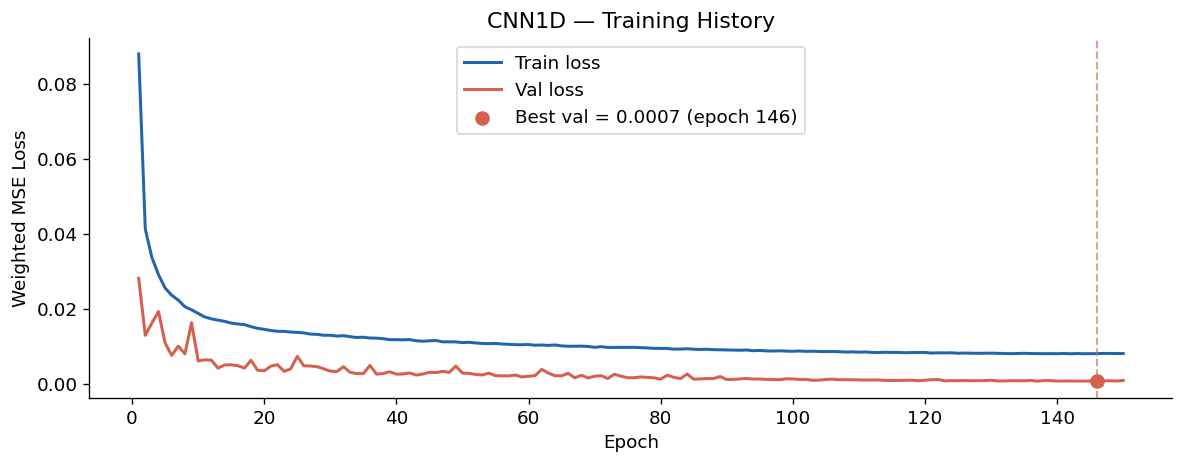

In [31]:
fig, ax = plt.subplots(figsize=(10, 4))

epochs = np.arange(1, len(history) + 1)
ax.plot(epochs, history['train_loss'], label='Train loss', color='#2166AC', lw=1.8)
ax.plot(epochs, history['val_loss'],   label='Val loss',   color='#D6604D', lw=1.8)

best_epoch = history['val_loss'].idxmin() + 1
best_val   = history['val_loss'].min()
ax.axvline(best_epoch, color='#D6604D', ls='--', lw=1.2, alpha=0.6)
ax.scatter([best_epoch], [best_val], color='#D6604D', zorder=5, s=60,
           label=f'Best val = {best_val:.4f} (epoch {best_epoch})')

ax.set_xlabel('Epoch')
ax.set_ylabel('Weighted MSE Loss')
ax.set_title('CNN1D — Training History')
ax.legend()
plt.tight_layout()
plt.show()

## 3. Model Comparison — R² per Molecule

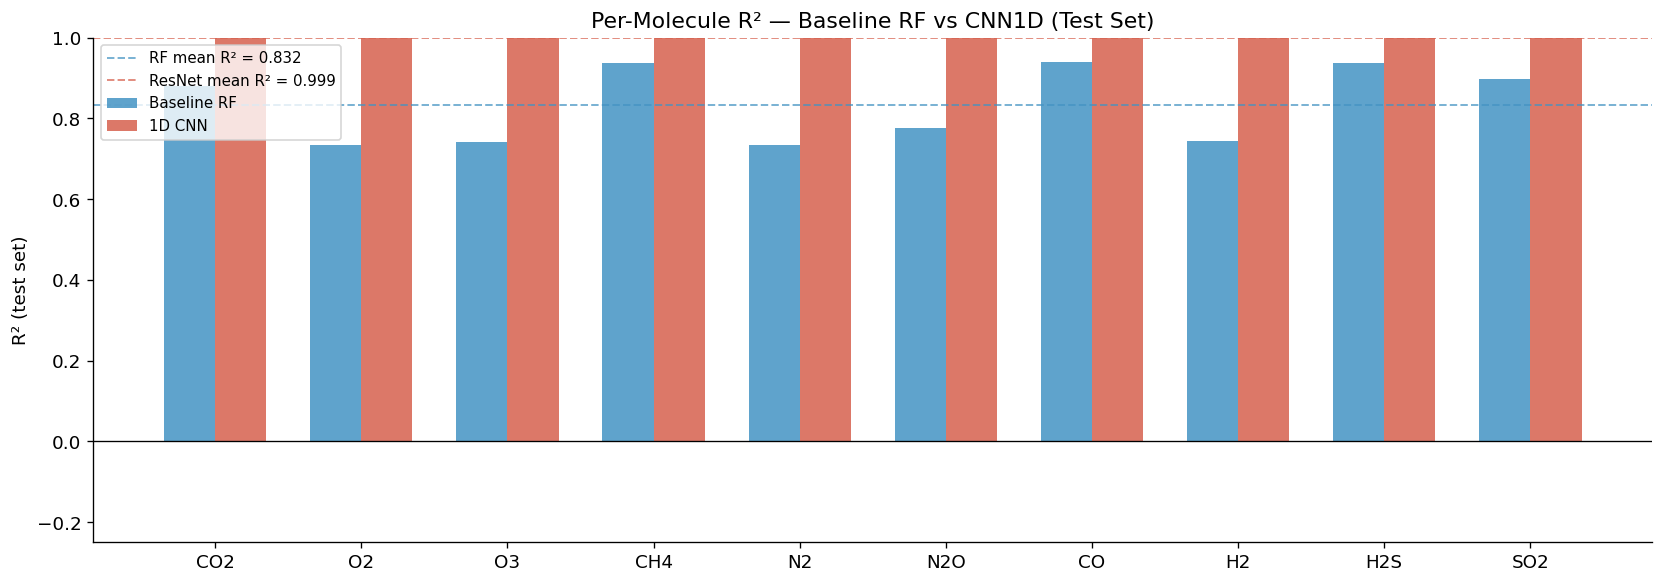

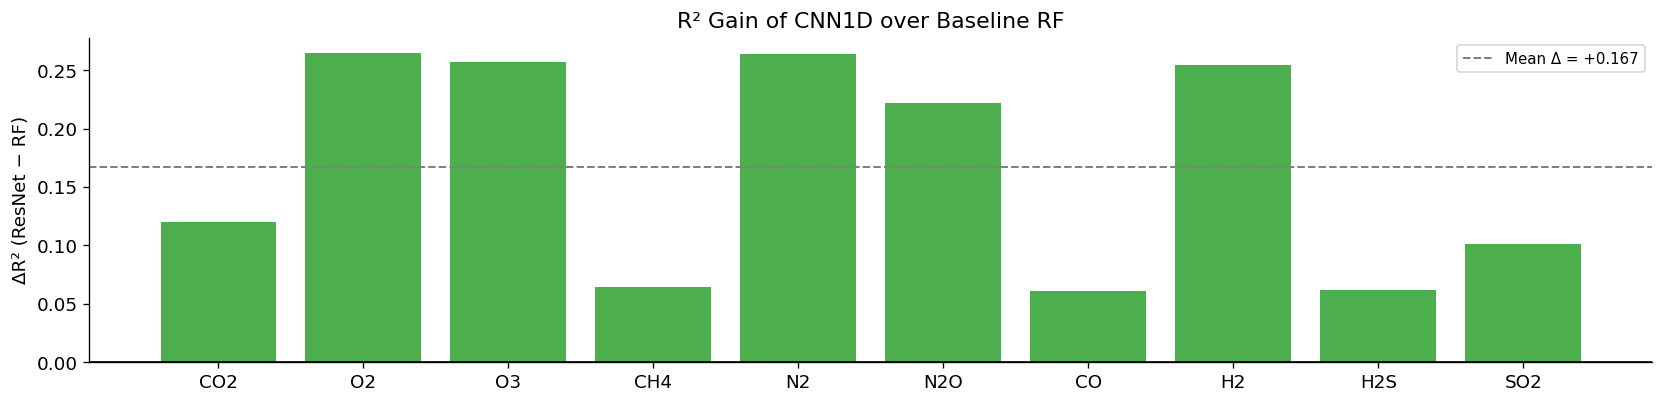

In [32]:
# Filter out MEAN row for per-molecule bars; keep MEAN for annotation
cmp = comparison[comparison['molecule'] != 'MEAN'].copy()
mean_row = comparison[comparison['molecule'] == 'MEAN'].iloc[0]

x = np.arange(len(cmp))
width = 0.35

fig, ax = plt.subplots(figsize=(14, 5))
bars_rf   = ax.bar(x - width/2, cmp['Baseline_R2'],  width, label='Baseline RF',   color='#4393C3', alpha=0.85)
bars_deep = ax.bar(x + width/2, cmp['DeepModel_R2'], width, label='1D CNN', color='#D6604D', alpha=0.85)

ax.axhline(0, color='black', lw=0.8)
ax.axhline(mean_row['Baseline_R2'],  color='#4393C3', ls='--', lw=1.2, alpha=0.7,
           label=f'RF mean R² = {mean_row["Baseline_R2"]:.3f}')
ax.axhline(mean_row['DeepModel_R2'], color='#D6604D', ls='--', lw=1.2, alpha=0.7,
           label=f'ResNet mean R² = {mean_row["DeepModel_R2"]:.3f}')

ax.set_xticks(x)
ax.set_xticklabels(cmp['molecule'])
ax.set_ylabel('R² (test set)')
ax.set_title('Per-Molecule R² — Baseline RF vs CNN1D (Test Set)')
ax.legend(fontsize=9)
ax.set_ylim(-0.25, 1.0)
plt.tight_layout()
plt.show()

# Delta R²
fig2, ax2 = plt.subplots(figsize=(14, 3.5))
colors = ['#2CA02C' if d >= 0 else '#D62728' for d in cmp['Delta_R2']]
ax2.bar(x, cmp['Delta_R2'], color=colors, alpha=0.85)
ax2.axhline(0, color='black', lw=1)
ax2.axhline(mean_row['Delta_R2'], color='grey', ls='--', lw=1.2,
            label=f'Mean Δ = {mean_row["Delta_R2"]:+.3f}')
ax2.set_xticks(x)
ax2.set_xticklabels(cmp['molecule'])
ax2.set_ylabel('ΔR² (ResNet − RF)')
ax2.set_title('R² Gain of CNN1D over Baseline RF')
ax2.legend(fontsize=9)
plt.tight_layout()
plt.show()

## 4. Predicted vs Actual — All 12 Molecules

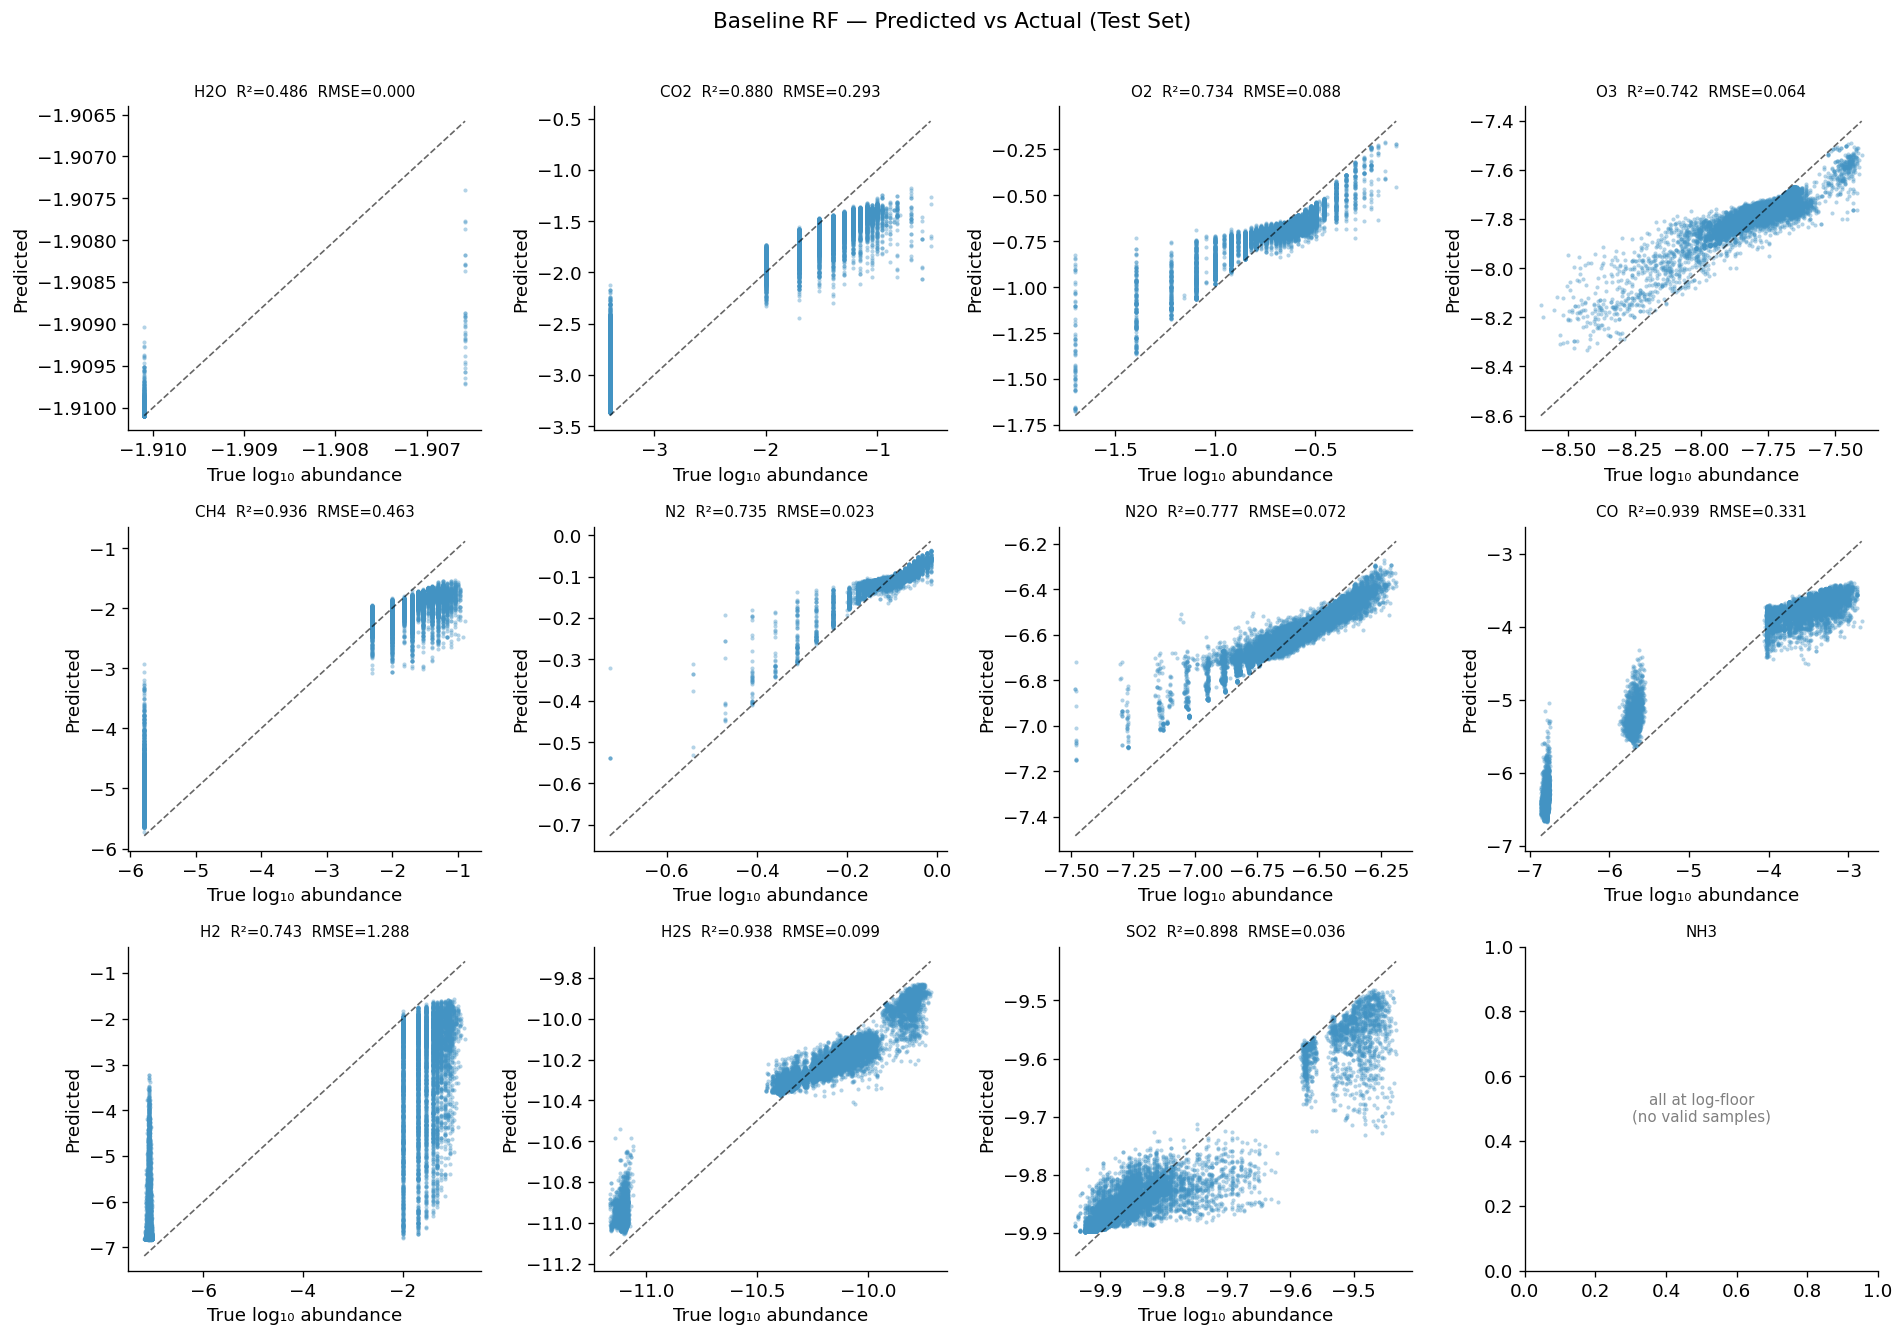

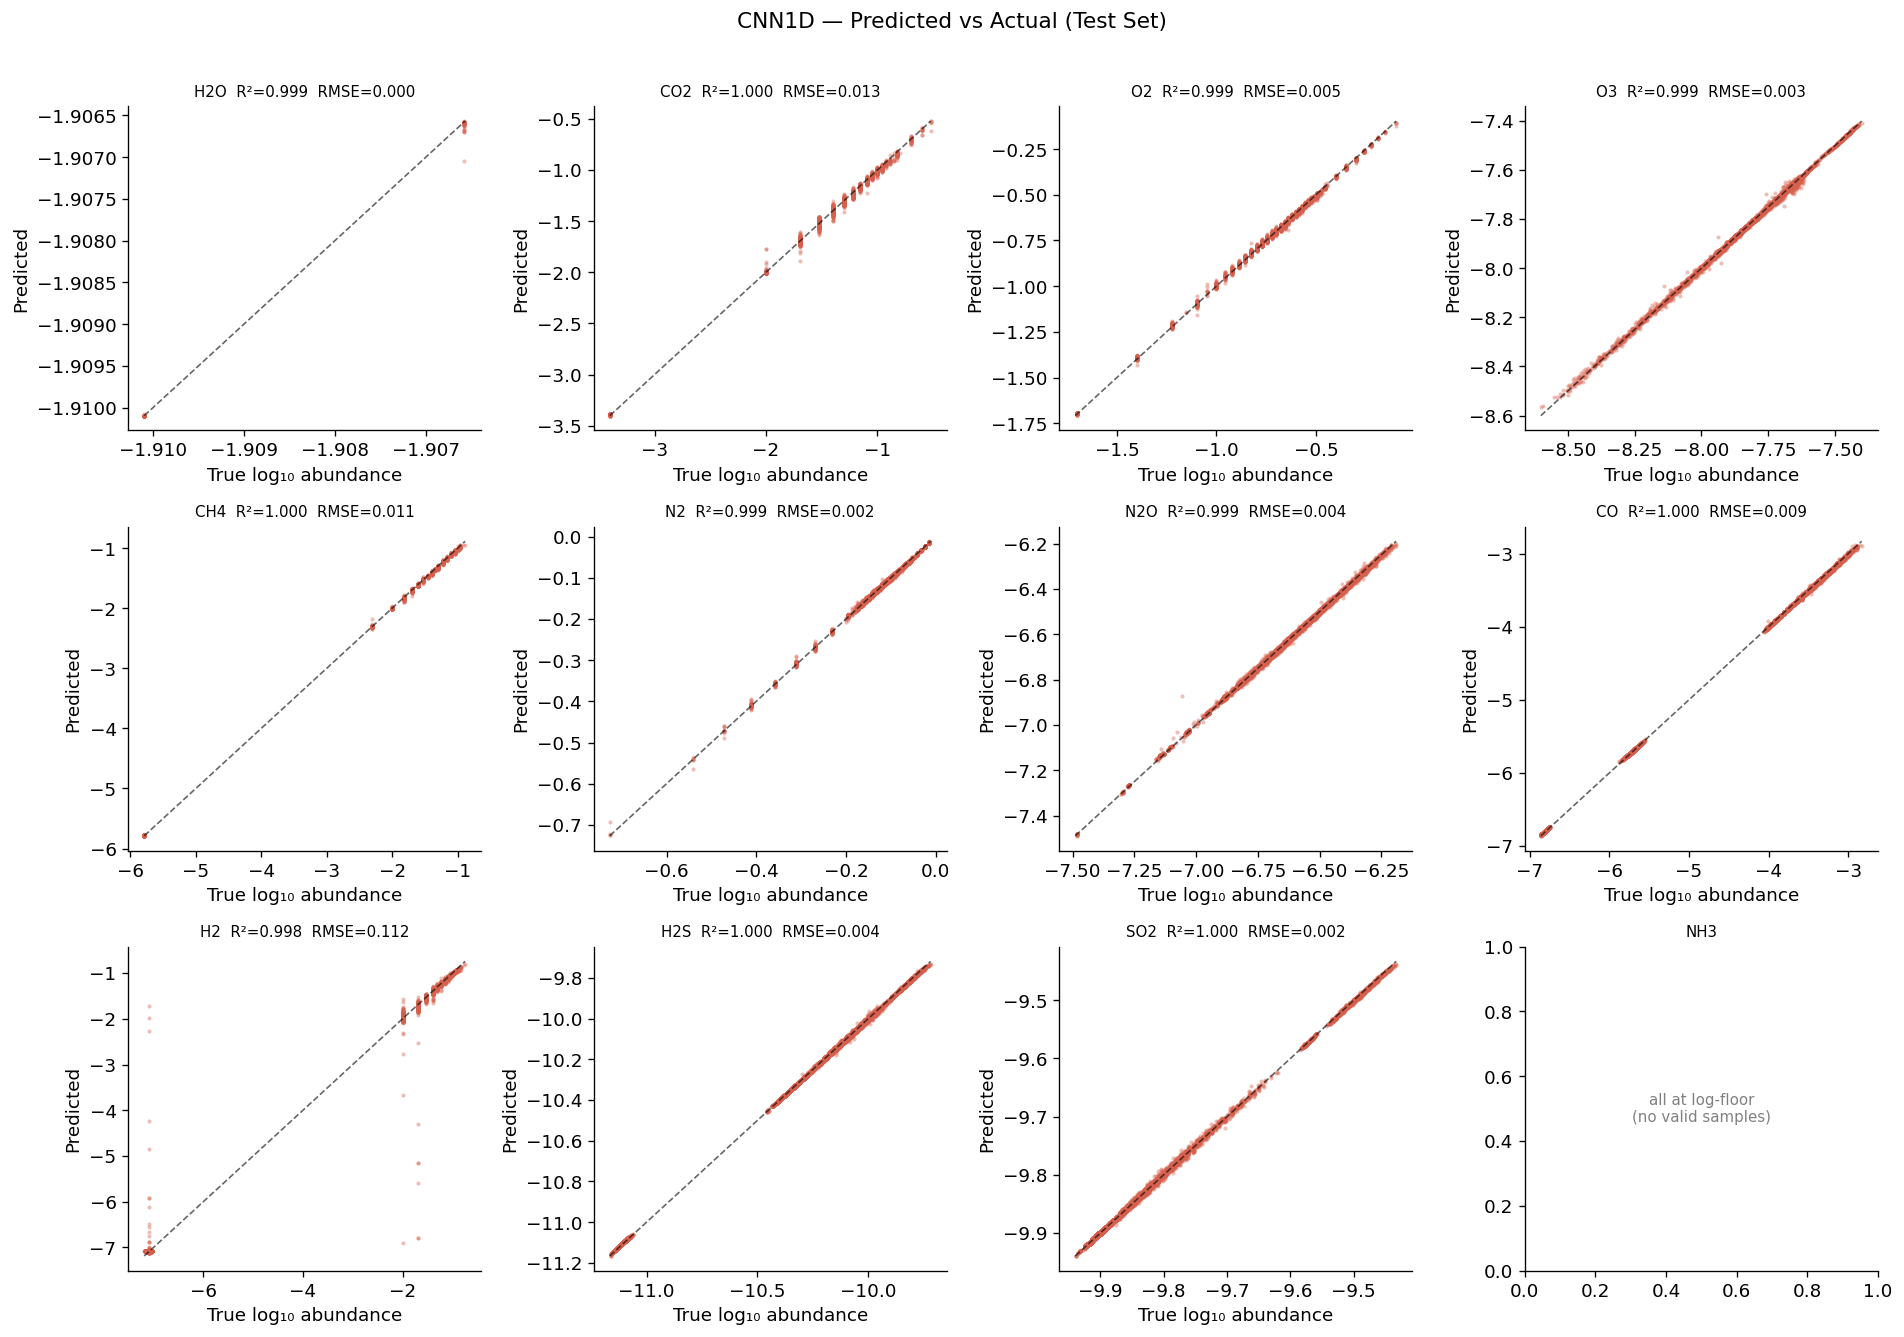

In [33]:
FLOOR = -40.0

def scatter_grid(y_true, y_pred, title, color, metrics_df):
    fig, axes = plt.subplots(3, 4, figsize=(16, 11))
    axes = axes.flatten()

    for i, (ax, mol) in enumerate(zip(axes, MOLECULE_NAMES)):
        yt, yp = y_true[:, i], y_pred[:, i]
        valid  = yt > FLOOR + 0.5

        if valid.sum() == 0:
            ax.text(0.5, 0.5, 'all at log-floor\n(no valid samples)',
                    ha='center', va='center', transform=ax.transAxes,
                    fontsize=9, color='grey')
            ax.set_title(mol, fontsize=9)
            continue

        yt_v, yp_v = yt[valid], yp[valid]
        ax.scatter(yt_v, yp_v, s=6, alpha=0.4, color=color, linewidths=0)

        lo = min(yt_v.min(), yp_v.min())
        hi = max(yt_v.max(), yp_v.max())
        ax.plot([lo, hi], [lo, hi], 'k--', lw=1, alpha=0.6)

        row = metrics_df[metrics_df['molecule'] == mol].iloc[0]
        ax.set_title(f'{mol}  R²={row["R2"]:.3f}  RMSE={row["RMSE"]:.3f}', fontsize=9)
        ax.set_xlabel('True log₁₀ abundance')
        ax.set_ylabel('Predicted')

    fig.suptitle(title, fontsize=13, y=1.01)
    plt.tight_layout()
    plt.show()

scatter_grid(y_true, rf_pred,   'Baseline RF — Predicted vs Actual (Test Set)',
             '#4393C3', rf_metrics)
scatter_grid(y_true, deep_pred, 'CNN1D — Predicted vs Actual (Test Set)',
             '#D6604D', deep_metrics)

## 5. Residual Distributions — Error Analysis

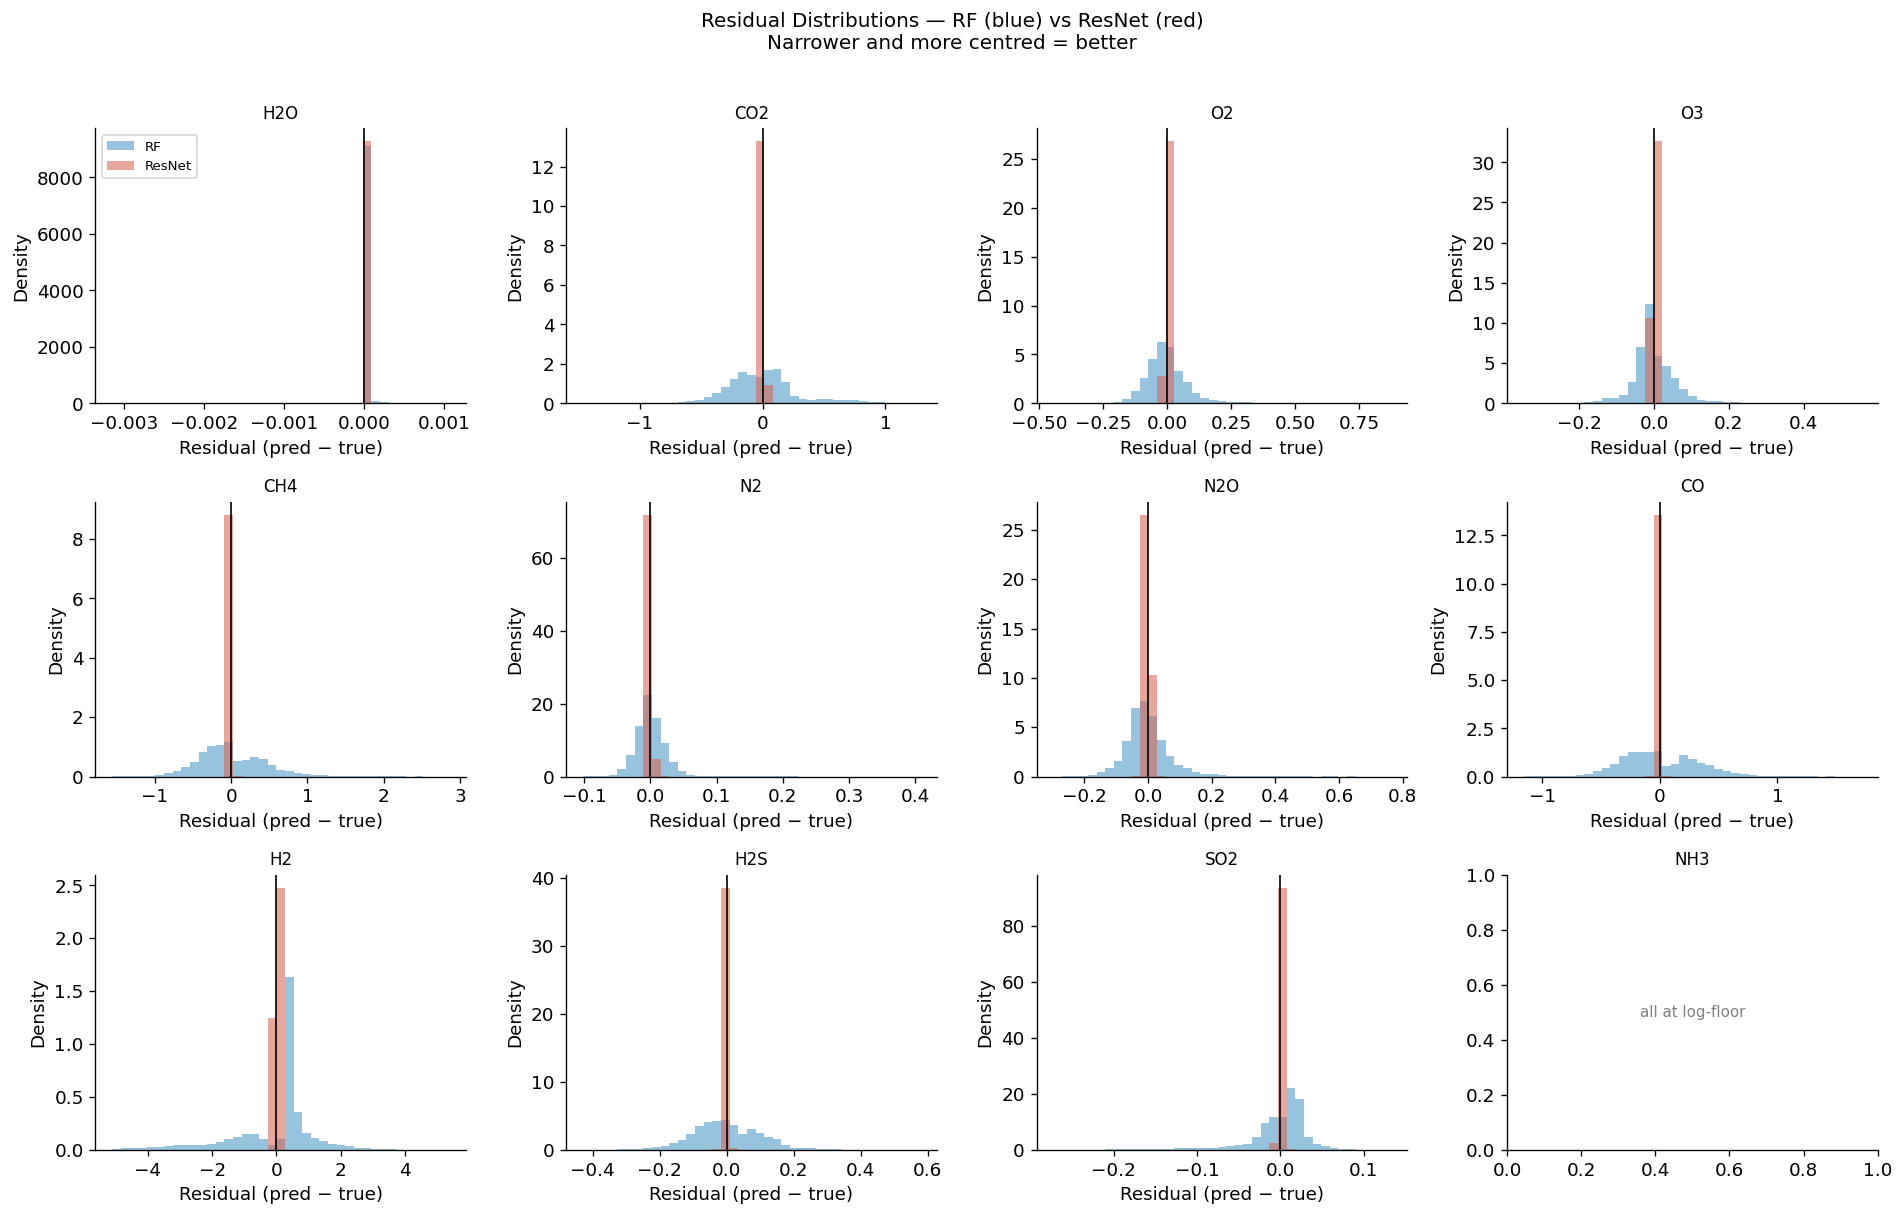

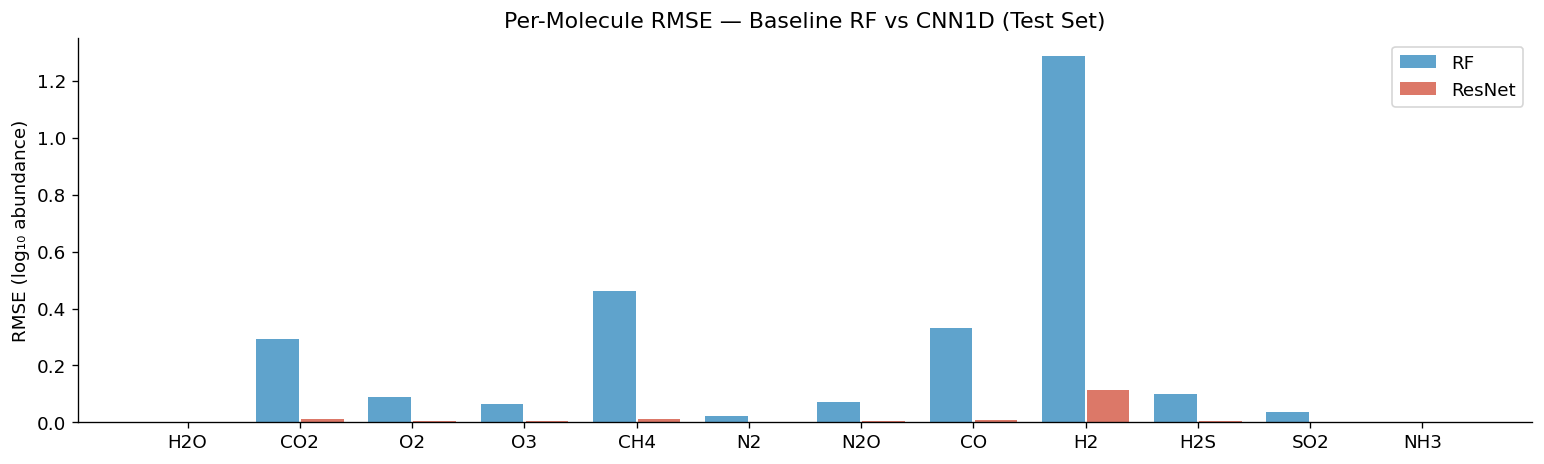

In [34]:
FLOOR = -40.0

fig, axes = plt.subplots(3, 4, figsize=(16, 10))
axes = axes.flatten()

for i, (ax, mol) in enumerate(zip(axes, MOLECULE_NAMES)):
    yt    = y_true[:, i]
    valid = yt > FLOOR + 0.5

    if valid.sum() == 0:
        ax.text(0.5, 0.5, 'all at log-floor', ha='center', va='center',
                transform=ax.transAxes, fontsize=9, color='grey')
        ax.set_title(mol, fontsize=10)
        continue

    res_rf   = rf_pred[valid, i]   - yt[valid]
    res_deep = deep_pred[valid, i] - yt[valid]

    lo   = min(res_rf.min(), res_deep.min())
    hi   = max(res_rf.max(), res_deep.max())
    bins = np.linspace(lo, hi, 40)

    ax.hist(res_rf,   bins=bins, alpha=0.55, color='#4393C3', label='RF',     density=True)
    ax.hist(res_deep, bins=bins, alpha=0.55, color='#D6604D', label='ResNet', density=True)
    ax.axvline(0, color='black', lw=1)
    ax.set_title(mol, fontsize=10)
    ax.set_xlabel('Residual (pred − true)')
    ax.set_ylabel('Density')
    if i == 0:
        ax.legend(fontsize=8)

fig.suptitle('Residual Distributions — RF (blue) vs ResNet (red)\n'
             'Narrower and more centred = better', fontsize=12, y=1.01)
plt.tight_layout()
plt.show()

# RMSE comparison bar chart
rf_rmse   = rf_metrics[rf_metrics['molecule'] != 'MEAN'].set_index('molecule')['RMSE']
deep_rmse = deep_metrics[deep_metrics['molecule'] != 'MEAN'].set_index('molecule')['RMSE']

fig2, ax2 = plt.subplots(figsize=(13, 4))
x = np.arange(len(MOLECULE_NAMES))
ax2.bar(x - 0.2, rf_rmse[MOLECULE_NAMES],   0.38, label='RF',     color='#4393C3', alpha=0.85)
ax2.bar(x + 0.2, deep_rmse[MOLECULE_NAMES], 0.38, label='ResNet', color='#D6604D', alpha=0.85)
ax2.set_xticks(x)
ax2.set_xticklabels(MOLECULE_NAMES)
ax2.set_ylabel('RMSE (log₁₀ abundance)')
ax2.set_title('Per-Molecule RMSE — Baseline RF vs CNN1D (Test Set)')
ax2.legend()
plt.tight_layout()
plt.show()

## 6. RF Feature Importance — Top PCA Components per Molecule

Each RF estimator was trained on PCA-reduced spectral features. Which principal components does each molecule rely on most?

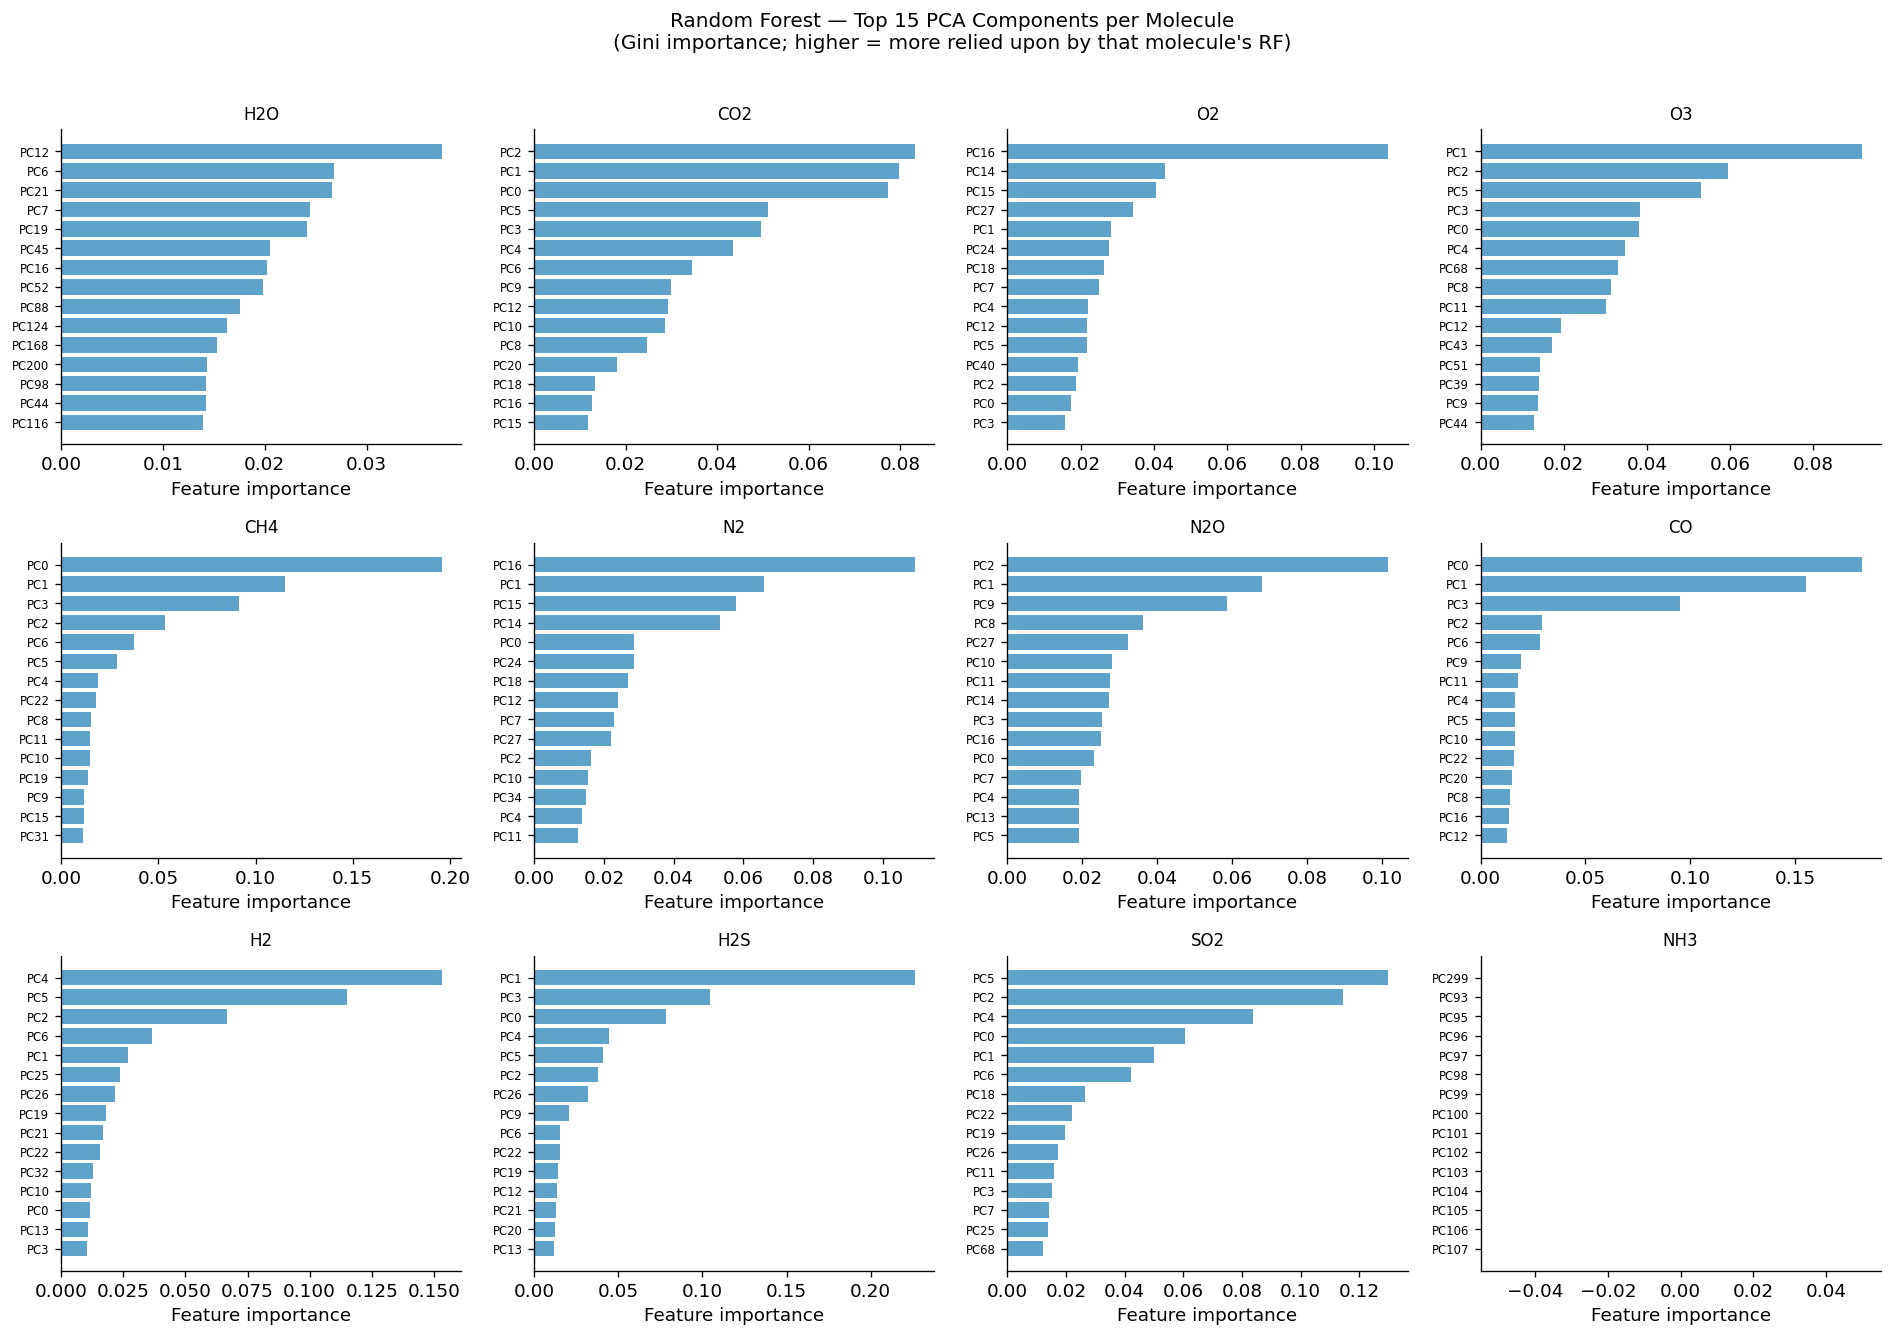

In [35]:
TOP_N = 15
importances = rf_model.feature_importance(top_n=TOP_N)

fig, axes = plt.subplots(3, 4, figsize=(16, 11))
axes = axes.flatten()

for ax, mol in zip(axes, MOLECULE_NAMES):
    feat_imp = importances[mol]   # list of (pca_idx, importance)
    idx_arr  = [f'PC{fi}' for fi, _ in feat_imp]
    imp_arr  = [imp for _, imp in feat_imp]

    bars = ax.barh(idx_arr[::-1], imp_arr[::-1], color='#4393C3', alpha=0.85)
    ax.set_title(mol, fontsize=10)
    ax.set_xlabel('Feature importance')
    ax.tick_params(axis='y', labelsize=7)

fig.suptitle(f'Random Forest — Top {TOP_N} PCA Components per Molecule\n'
             '(Gini importance; higher = more relied upon by that molecule\'s RF)',
             fontsize=12, y=1.01)
plt.tight_layout()
plt.show()

## 7. 1D CNN Architecture — Parameter Counts per Layer

Break down where the ~parameters live in the CNN1D model.

Total trainable parameters: 368,588

Stage                               Params   % Total
------------------------------------------------------
Conv Block 1 (12→32)                 3,520      1.0%
Conv Block 2 (32→64)                14,464      3.9%
Conv Block 3 (64→128)               41,216     11.2%
Conv Block 4 (128→256)              98,816     26.8%
Shared FC (256→128)                 33,152      9.0%
12 Molecule Heads                  177,420     48.1%


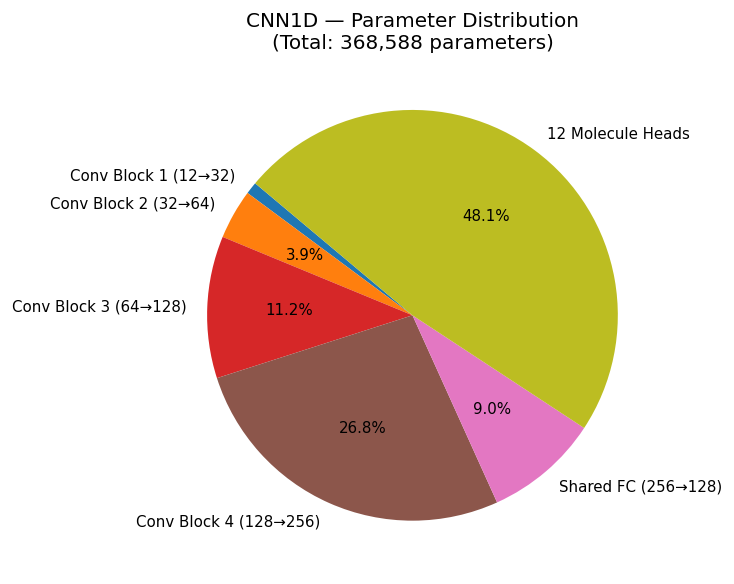


Per-molecule head parameter counts:
  H2O  : 16,897
  CO2  : 8,449
  O2   : 8,449
  O3   : 16,897
  CH4  : 16,897
  N2   : 8,449
  N2O  : 16,897
  CO   : 16,897
  H2   : 16,897
  H2S  : 16,897
  SO2  : 16,897
  NH3  : 16,897


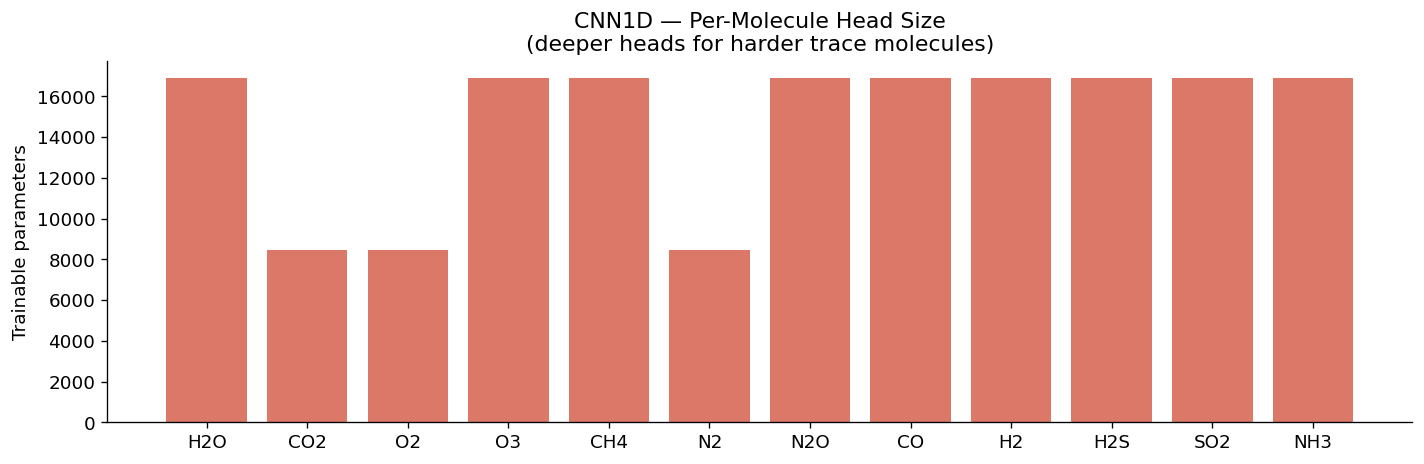

In [36]:
def count_params(module):
    return sum(p.numel() for p in module.parameters() if p.requires_grad)

stages = [
    ('Conv Block 1 (12→32)',  model.backbone[0:4]),
    ('Conv Block 2 (32→64)',  model.backbone[4:8]),
    ('Conv Block 3 (64→128)', model.backbone[8:12]),
    ('Conv Block 4 (128→256)',model.backbone[12:]),
    ('Shared FC (256→128)',   model.shared),
    ('12 Molecule Heads',     model.heads),
]

stage_names  = [s for s, _ in stages]
stage_params = [count_params(m) for _, m in stages]
total_params = model.count_parameters()

print(f'Total trainable parameters: {total_params:,}\n')
print(f'{"Stage":<30s}  {"Params":>10s}  {"% Total":>8s}')
print('-' * 54)
for name, n in zip(stage_names, stage_params):
    print(f'{name:<30s}  {n:>10,}  {100*n/total_params:>7.1f}%')

fig, ax = plt.subplots(figsize=(10, 5))
colors = plt.cm.tab10(np.linspace(0, 0.85, len(stages)))
wedges, texts, autotexts = ax.pie(
    stage_params,
    labels=stage_names,
    colors=colors,
    autopct=lambda p: f'{p:.1f}%' if p > 3 else '',
    startangle=140,
    textprops={'fontsize': 9},
)
ax.set_title(f'CNN1D — Parameter Distribution\n'
             f'(Total: {total_params:,} parameters)', fontsize=12)
plt.tight_layout()
plt.show()

# Per-molecule head breakdown
print('\nPer-molecule head parameter counts:')
head_names, head_params = [], []
for mol in MOLECULE_NAMES:
    n = count_params(model.heads[mol])
    head_names.append(mol)
    head_params.append(n)
    print(f'  {mol:5s}: {n:,}')

fig2, ax2 = plt.subplots(figsize=(12, 4))
ax2.bar(head_names, head_params, color='#D6604D', alpha=0.85)
ax2.set_ylabel('Trainable parameters')
ax2.set_title('CNN1D — Per-Molecule Head Size\n'
              '(deeper heads for harder trace molecules)')
plt.tight_layout()
plt.show()

## 8. 1D CNN Architecture Diagram — Horizontal Layout

End-to-end view: input CLIMA profile → 4 conv blocks → global pool → shared FC → 12 per-molecule heads → log₁₀ abundances.

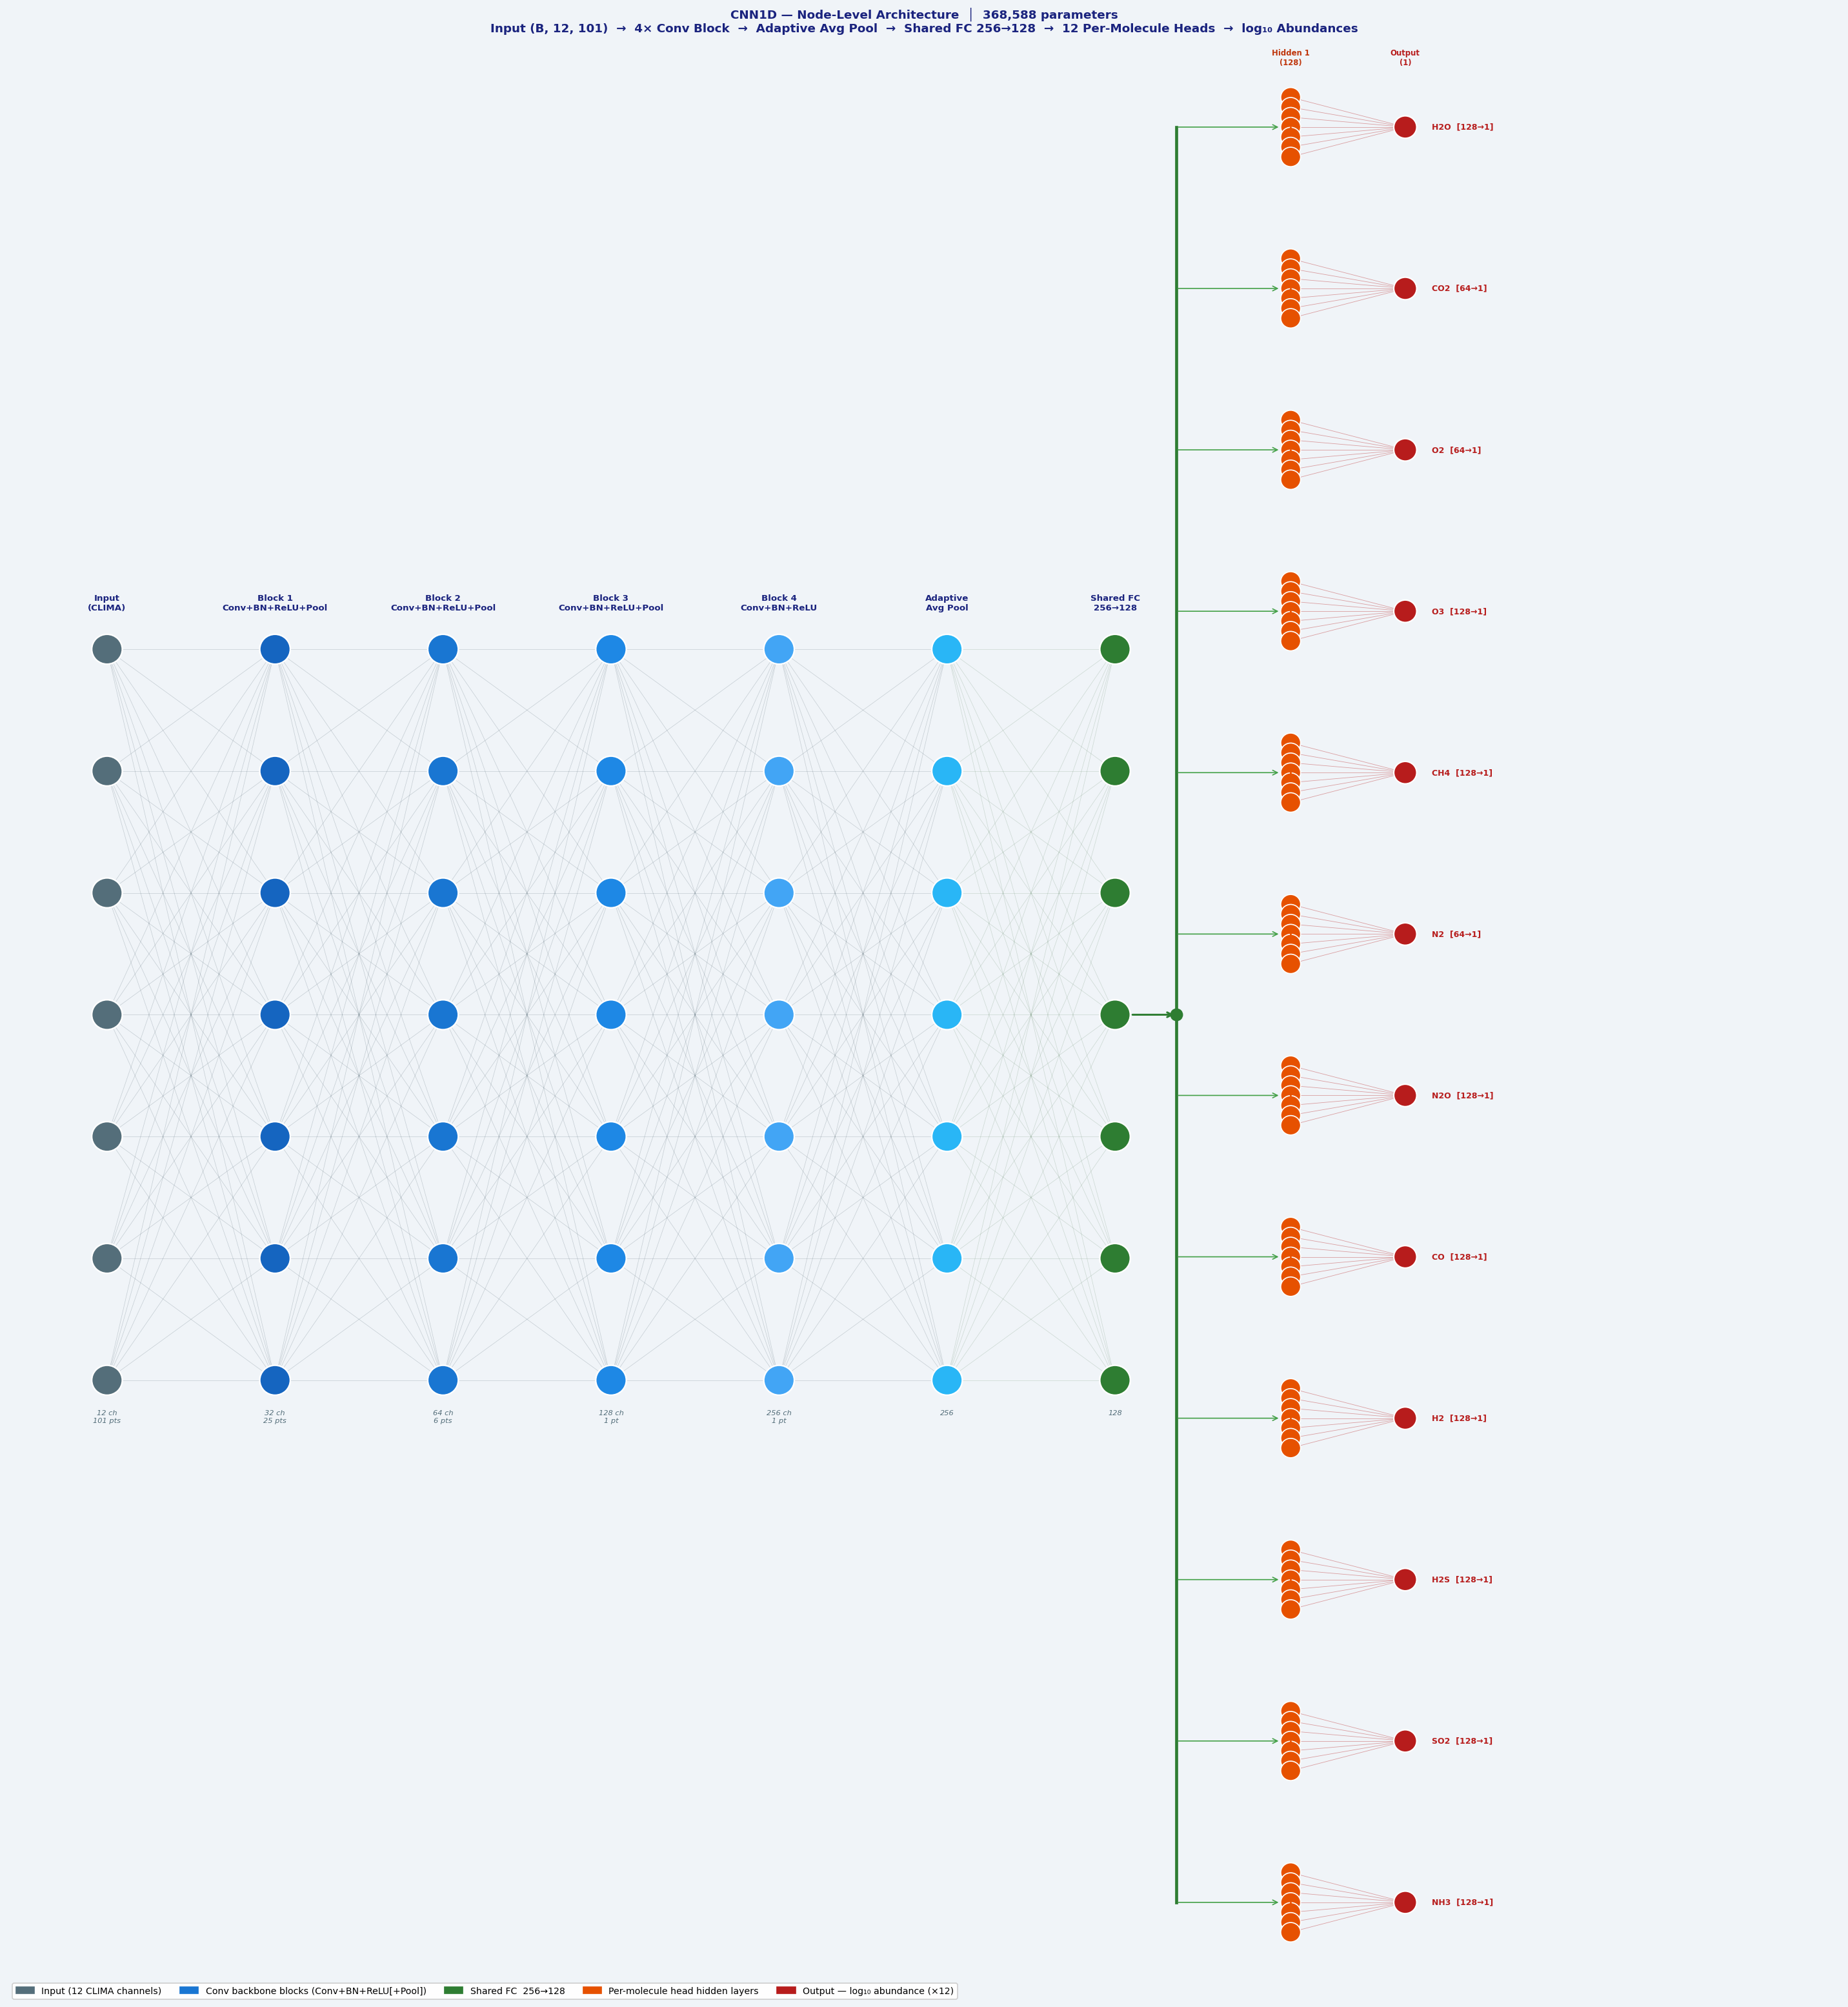

In [41]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# ── Introspect model from checkpoint ─────────────────────────────────────────
with torch.no_grad():
    _in_ch = model.in_channels
    _seq   = spectra.shape[2] if "spectra" in dir() else 101

    def _split_blocks(backbone):
        """Split nn.Sequential into blocks, starting a new block at each Conv1d."""
        blocks, cur = [], []
        for layer in backbone:
            if isinstance(layer, nn.Conv1d) and cur:
                blocks.append(cur)
                cur = []
            cur.append(layer)
        if cur:
            blocks.append(cur)
        return blocks

    blocks = _split_blocks(model.backbone)

    # Simulate forward to record output shapes after each block
    x = torch.zeros(1, _in_ch, _seq)
    block_info = []
    for i, blk in enumerate(blocks):
        for layer in blk:
            x = layer(x)
        has_pool = any(isinstance(l, (nn.MaxPool1d, nn.AvgPool1d)) for l in blk)
        pool_str = "+Pool" if has_pool else ""
        out_ch, spatial = x.shape[1], x.shape[2]
        block_info.append({
            "label":   f"Block {i+1}\nConv+BN+ReLU{pool_str}",
            "sub":     f"{out_ch} ch\n{spatial} pt{'s' if spatial > 1 else ''}",
            "n_nodes": out_ch,
        })

    # Adaptive pool output dim
    x_pooled  = model.pool(x).squeeze(-1)
    pool_dim  = x_pooled.shape[1]

    # Shared FC: first Linear in model.shared
    shared_in  = pool_dim
    shared_out = next(l.out_features for l in model.shared if isinstance(l, nn.Linear))

    # Per-molecule head hidden dims (all Linear.out_features except final output layer)
    def _head_dims(head):
        linears = [l for l in head.net if isinstance(l, nn.Linear)]
        return [l.out_features for l in linears[:-1]]

# ── Layout constants ──────────────────────────────────────────────────────────
MAX_SHOWN = 7
DOT_R     = 0.20
FIG_W, FIG_H = 24, 26
MID_Y     = FIG_H / 2

fig, ax = plt.subplots(figsize=(FIG_W, FIG_H))
ax.set_xlim(0, FIG_W); ax.set_ylim(0, FIG_H); ax.axis("off")
fig.patch.set_facecolor("#F0F4F8"); ax.set_facecolor("#F0F4F8")

# ── Helpers ───────────────────────────────────────────────────────────────────
def node_ys(n, cy, spread):
    return np.linspace(cy + spread/2, cy - spread/2, min(n, MAX_SHOWN))

def draw_column(ax, cx, n, color, label, sublabel, cy=MID_Y, spread=9.8, r=DOT_R, fs=8):
    ys = node_ys(n, cy, spread)
    for y in ys:
        ax.add_patch(plt.Circle((cx, y), r, color=color, ec="white", lw=1.4, zorder=4))
    if n > MAX_SHOWN:
        ax.text(cx, cy, "⋮", ha="center", va="center", fontsize=15,
                color=color, fontweight="bold", zorder=5)
    ax.text(cx, ys[0]  + r + 0.30, label,    ha="center", va="bottom",
            fontsize=fs, fontweight="bold", color="#1A237E", zorder=5)
    ax.text(cx, ys[-1] - r - 0.20, sublabel, ha="center", va="top",
            fontsize=6.8, color="#546E7A", style="italic", zorder=5)
    return ys

def connect(ax, cx1, ys1, cx2, ys2, color="#90A4AE", alpha=0.15, lw=0.5):
    for y1 in ys1:
        for y2 in ys2:
            ax.plot([cx1, cx2], [y1, y2], color=color, alpha=alpha, lw=lw, zorder=1)

# ── Build backbone columns from introspected data ─────────────────────────────
CONV_COLORS = ["#1565C0", "#1976D2", "#1E88E5", "#42A5F5", "#64B5F6"]

COLS = [(1.3, _in_ch, "#546E7A", "Input\n(CLIMA)", f"{_in_ch} ch\n{_seq} pts", "#78909C")]
cx = 3.5
for i, bi in enumerate(block_info):
    COLS.append((cx, bi["n_nodes"], CONV_COLORS[i % len(CONV_COLORS)],
                 bi["label"], bi["sub"], "#092634"))
    cx += 2.2
COLS.append((cx, pool_dim,   "#29B6F6", "Adaptive\nAvg Pool",
             str(pool_dim),  "#102934"))
cx += 2.2
COLS.append((cx, shared_out, "#2E7D32",
             f"Shared FC\n{shared_in}→{shared_out}", str(shared_out), "#2D6030"))

prev_ys, prev_cx = None, None
for (cx, n, color, label, sub, conn_color) in COLS:
    ys = draw_column(ax, cx, n, color, label, sub)
    if prev_ys is not None:
        connect(ax, prev_cx, prev_ys, cx, ys, color=conn_color, alpha=0.18, lw=0.45)
    prev_ys, prev_cx = ys, cx

shared_cx = COLS[-1][0]

# ── Bus line: Shared FC → 12 molecule heads ───────────────────────────────────
BUS_X    = shared_cx + 0.8
mol_mids = np.linspace(FIG_H - 1.1, 1.1, 12)

ax.plot([BUS_X, BUS_X], [mol_mids[-1], mol_mids[0]],
        color="#2E7D32", lw=2.8, zorder=2)
ax.scatter([BUS_X], [MID_Y], s=120, color="#2E7D32", zorder=5)
ax.annotate("", xy=(BUS_X, MID_Y), xytext=(shared_cx + DOT_R, MID_Y),
            arrowprops=dict(arrowstyle="->", color="#2E7D32", lw=1.8), zorder=3)

# ── Head columns (introspected per-molecule dims) ─────────────────────────────
HEAD_SPREAD = 0.80
HEAD_R      = 0.13
HEAD_COLORS = ["#E65100", "#F4511E", "#FF7043"]
OUT_COLOR   = "#B71C1C"
COL_STEP    = 1.5

for mol, cy in zip(MOLECULE_NAMES, mol_mids):
    hdims   = _head_dims(model.heads[mol])
    col_xs  = [BUS_X + COL_STEP * (j + 1) for j in range(len(hdims))]
    out_x   = BUS_X + COL_STEP * (len(hdims) + 1)

    ax.annotate("", xy=(col_xs[0] - HEAD_R, cy), xytext=(BUS_X, cy),
                arrowprops=dict(arrowstyle="->", color="#43A047", lw=1.0), zorder=2)

    prev_hx, prev_hys = None, None
    for hi, (hx, hdim) in enumerate(zip(col_xs, hdims)):
        c   = HEAD_COLORS[hi % len(HEAD_COLORS)]
        hys = node_ys(hdim, cy, HEAD_SPREAD)
        for y in hys:
            ax.add_patch(plt.Circle((hx, y), HEAD_R, color=c, ec="white", lw=1.0, zorder=4))
        if hdim > MAX_SHOWN:
            ax.text(hx, cy, "⋮", ha="center", va="center", fontsize=9,
                    color=c, fontweight="bold", zorder=5)
        if cy == mol_mids[0]:
            ax.text(hx, cy + HEAD_SPREAD/2 + HEAD_R + 0.28,
                    f"Hidden {hi+1}\n({hdim})", ha="center", va="bottom",
                    fontsize=7, fontweight="bold", color="#BF360C", zorder=5)
        if prev_hys is not None:
            connect(ax, prev_hx, prev_hys, hx, hys, color=c, alpha=0.22, lw=0.5)
        prev_hx, prev_hys = hx, hys

    ax.add_patch(plt.Circle((out_x, cy), HEAD_R + 0.02,
                             color=OUT_COLOR, ec="white", lw=1.3, zorder=4))
    connect(ax, prev_hx, prev_hys, out_x, [cy], color=OUT_COLOR, alpha=0.4, lw=0.5)
    if cy == mol_mids[0]:
        ax.text(out_x, cy + HEAD_SPREAD/2 + HEAD_R + 0.28, "Output\n(1)",
                ha="center", va="bottom", fontsize=7, fontweight="bold",
                color=OUT_COLOR, zorder=5)
    dim_str = "→".join([str(d) for d in hdims] + ["1"])
    ax.text(out_x + 0.35, cy, f"{mol}  [{dim_str}]",
            ha="left", va="center", fontsize=7.5,
            color=OUT_COLOR, fontweight="bold", zorder=5)

# ── Legend ────────────────────────────────────────────────────────────────────
legend_items = [
    mpatches.Patch(color="#546E7A", label=f"Input ({_in_ch} CLIMA channels)"),
    mpatches.Patch(color="#1976D2", label="Conv backbone blocks (Conv+BN+ReLU[+Pool])"),
    mpatches.Patch(color="#2E7D32", label=f"Shared FC  {shared_in}→{shared_out}"),
    mpatches.Patch(color="#E65100", label="Per-molecule head hidden layers"),
    mpatches.Patch(color="#B71C1C", label="Output — log₁₀ abundance (×12)"),
]
ax.legend(handles=legend_items, loc="lower left", fontsize=8.5,
          framealpha=0.95, ncol=5, bbox_to_anchor=(0.0, -0.01), edgecolor="#CCCCCC")

ax.set_title(
    f"CNN1D — Node-Level Architecture  │  {model.count_parameters():,} parameters\n"
    f"Input (B, {_in_ch}, {_seq})  →  {len(block_info)}× Conv Block  →  Adaptive Avg Pool"
    f"  →  Shared FC {shared_in}→{shared_out}  →  12 Per-Molecule Heads  →  log₁₀ Abundances",
    fontsize=11, fontweight="bold", pad=12, color="#1A237E"
)

plt.tight_layout()
plt.show()


## 8. Summary Table

In [38]:
summary = comparison.copy()
summary['Baseline_RMSE'] = rf_metrics.set_index('molecule').reindex(summary['molecule'])['RMSE'].values
summary['Deep_RMSE']     = deep_metrics.set_index('molecule').reindex(summary['molecule'])['RMSE'].values
summary['Winner'] = summary.apply(
    lambda r: '1D CNN' if r['DeepModel_R2'] > r['Baseline_R2'] else 'RF',
    axis=1
)
summary.loc[summary['molecule'] == 'MEAN', 'Winner'] = ''

display_cols = ['molecule', 'Baseline_R2', 'DeepModel_R2', 'Delta_R2',
                'Baseline_RMSE', 'Deep_RMSE', 'Winner']
print(summary[display_cols].to_string(index=False, float_format='%.4f'))

molecule  Baseline_R2  DeepModel_R2  Delta_R2  Baseline_RMSE  Deep_RMSE Winner
     CO2       0.8797        0.9998    0.1201         0.2935     0.0126 1D CNN
      O2       0.7344        0.9991    0.2646         0.0884     0.0052 1D CNN
      O3       0.7424        0.9993    0.2568         0.0636     0.0034 1D CNN
     CH4       0.9359        1.0000    0.0641         0.4627     0.0107 1D CNN
      N2       0.7352        0.9988    0.2636         0.0227     0.0015 1D CNN
     N2O       0.7771        0.9993    0.2222         0.0722     0.0041 1D CNN
      CO       0.9388        1.0000    0.0612         0.3313     0.0093 1D CNN
      H2       0.7434        0.9981    0.2546         1.2881     0.1121 1D CNN
     H2S       0.9379        0.9999    0.0620         0.0990     0.0038 1D CNN
     SO2       0.8985        0.9998    0.1013         0.0355     0.0017 1D CNN
    MEAN       0.8323        0.9994    0.1671         0.2298     0.0137       
